In [0]:
#  %tensorflow_version 2.x  
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras import models

import os
import tensorflow as tf
import numpy as np
from numpy import expand_dims
import matplotlib.pyplot as plt

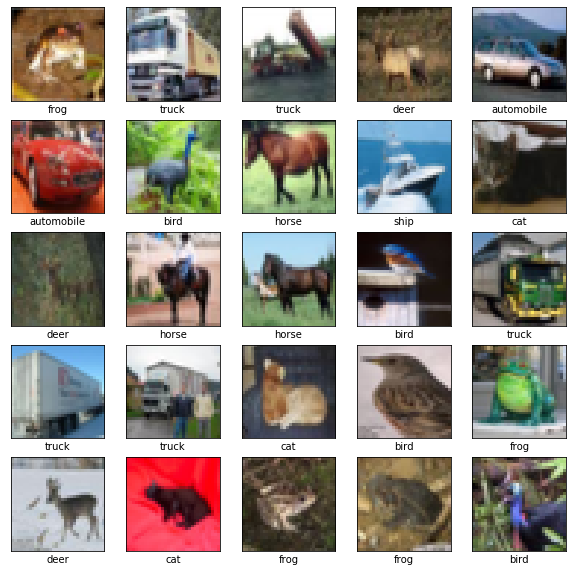

Train data Shape:(50000, 32, 32, 3)
Train label shape:(50000,)


In [3]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0
train_labels, test_labels = train_labels.reshape((-1,)).astype(np.int32), test_labels.reshape((-1,)).astype(np.int32)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i]])
plt.show()

print("Train data Shape:"+ str(train_images.shape)) #50000 images of 32X32 pixels 3 channels(RGB)
print("Train label shape:"+ str(train_labels.shape))
# data = tf.data.Dataset.from_tensor_slices(
#     (train_images.reshape([-1, 32, 32, 3]).astype(np.float32) / 255, train_labels.reshape((-1,)).astype(np.int32)))
# data = data.shuffle(buffer_size=50000).batch(128).repeat()

# # note: we batch the test data, but do not shuffle/repeat
# test_data = tf.data.Dataset.from_tensor_slices(
#     (test_images.reshape([-1, 32, 32, 3]).astype(np.float32) / 255, test_labels.reshape((-1,)).astype(np.int32))).batch(128)


In [0]:
def plotLosses(history):  
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

In [0]:
def plotAccuracies(history):  
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0.5, 1])
    plt.legend(loc='upper right')
    plt.show()

In [0]:
#Model with dropouts to avoid overfitting
def model4(input_shape):
  layer_list = [tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape = input_shape),
                  tf.keras.layers.MaxPooling2D(2,2),
                  # tf.keras.layers.Dropout(0.25), #Addition of layer here
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.MaxPooling2D(2,2),
                  tf.keras.layers.Dropout(0.25), #Addition of layer here
                  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
                  tf.keras.layers.Flatten(),
                  tf.keras.layers.Dense(64),
                  tf.keras.layers.Dropout(0.5),
                  tf.keras.layers.Dense(10, activation= 'softmax')]  
  model = tf.keras.Sequential(layer_list)
  return model
  return model

# **VISUALIZATION**

In [0]:
def run_model_with_imagegenerator(model):
  model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  history = model.fit_generator(train_datagen.flow(train_images, train_labels,batch_size=64),
                        epochs=10,
                        validation_data=(test_images, test_labels))
  plotLosses(history)
  plotAccuracies(history)

Epoch 1/10
782/782 [==============================] - 109s 139ms/step - loss: 1.6206 - accuracy: 0.4097 - val_loss: 1.3486 - val_accuracy: 0.5310
Epoch 2/10
782/782 [==============================] - 103s 132ms/step - loss: 1.2864 - accuracy: 0.5434 - val_loss: 1.0497 - val_accuracy: 0.6288
Epoch 3/10
782/782 [==============================] - 97s 124ms/step - loss: 1.1591 - accuracy: 0.5934 - val_loss: 0.9731 - val_accuracy: 0.6592
Epoch 4/10
782/782 [==============================] - 109s 140ms/step - loss: 1.0874 - accuracy: 0.6212 - val_loss: 0.8958 - val_accuracy: 0.6911
Epoch 5/10
782/782 [==============================] - 106s 135ms/step - loss: 1.0349 - accuracy: 0.6401 - val_loss: 0.8558 - val_accuracy: 0.7049
Epoch 6/10
782/782 [==============================] - 106s 136ms/step - loss: 0.9842 - accuracy: 0.6558 - val_loss: 0.8586 - val_accuracy: 0.7008
Epoch 7/10
782/782 [==============================] - 101s 129ms/step - loss: 0.9616 - accuracy: 0.6660 - val_loss: 0.8698 - 

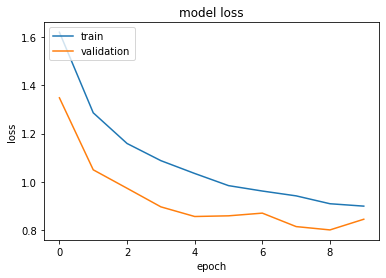

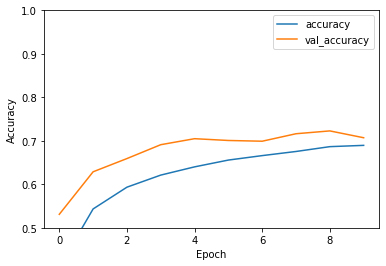

In [8]:
train_datagen = ImageDataGenerator(
        width_shift_range=0.1,  # Horizontal shift (10% of total width)
        height_shift_range=0.1,  # Vertical shift (10% of total height)
        horizontal_flip=True)   # flipping images horizontally . // Not advisable for medical data

train_datagen.fit(train_images)

input_shape = (32,32,3)
model = model4(input_shape)
run_model_with_imagegenerator(model)

In [0]:
def visualise(img):
  plt.imshow(img, cmap=plt.cm.binary)

  img = img_to_array(img)
  img = expand_dims(img, axis=0)
  print(img.shape)

  layer_outputs = [layer.output for layer in model.layers[:10]] 
  # Extracts the outputs of the top 12 layers
  activation_model = models.Model(inputs=model.input, outputs=layer_outputs) # Creates a model that will return these outputs, given the model input
  activations = activation_model.predict(img) # Returns a list of five Numpy arrays: one array per layer activation

  layer_names = []
  for layer in model.layers:
      layer_names.append(layer.name)
    
  images_per_row = 8
  for layer_name, layer_activation in zip(layer_names, activations): 
      n_features = layer_activation.shape[-1] # Number of features in the feature map
      size = layer_activation.shape[1] #The feature map has shape (1, size, size, n_features).
      n_cols = n_features // images_per_row # Tiles the activation channels in this matrix
      display_grid = np.zeros((size * n_cols, images_per_row * size))
      for col in range(n_cols): # Tiles each filter into a big horizontal grid
          for row in range(images_per_row):
              channel_image = layer_activation[0,:, :,col * images_per_row + row]
            # channel_image -= channel_image.mean() # Post-processes the feature to make it visually palatable
            # channel_image /= channel_image.std()
            # channel_image *= 64
            # channel_image += 128
            # channel_image = np.clip(channel_image, 0, 255).astype('uint8')
              display_grid[col * size : (col + 1) * size, # Displays the grid
                         row * size : (row + 1) * size] = channel_image
      scale = 1. / size
      plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
      plt.title(layer_name)
      plt.grid(False)

      plt.grid(False)
      plt.imshow(display_grid, cmap='viridis')
    # plt.imshow(display_grid, aspect='auto', cmap='viridis')


(1, 32, 32, 3)


IndexError: ignored

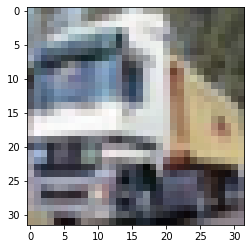

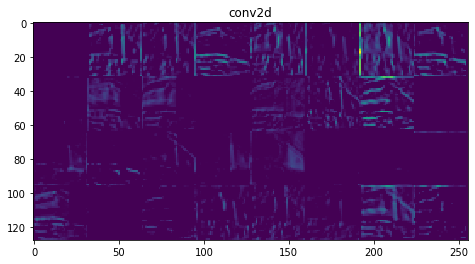

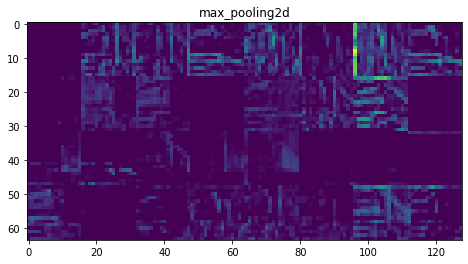

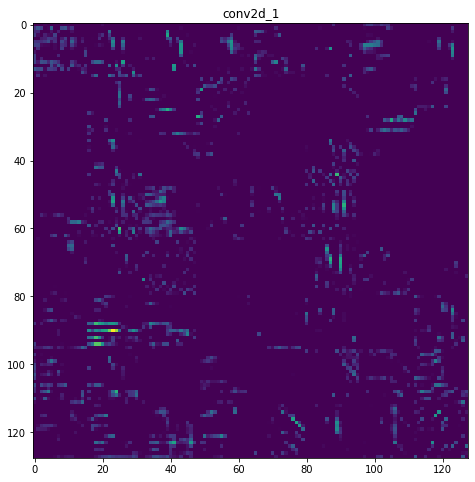

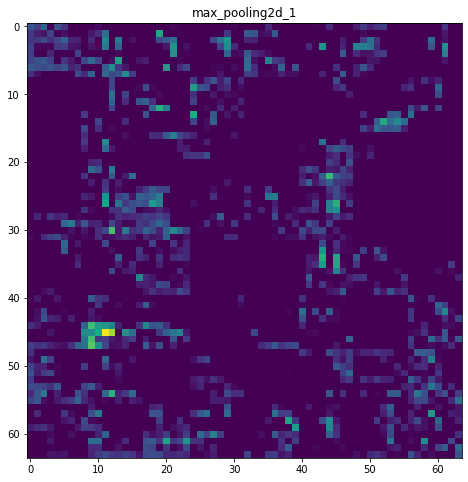

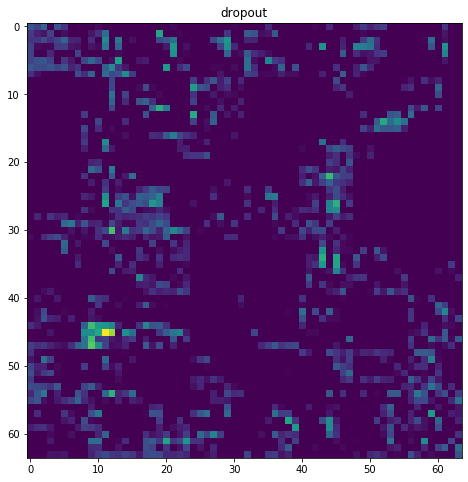

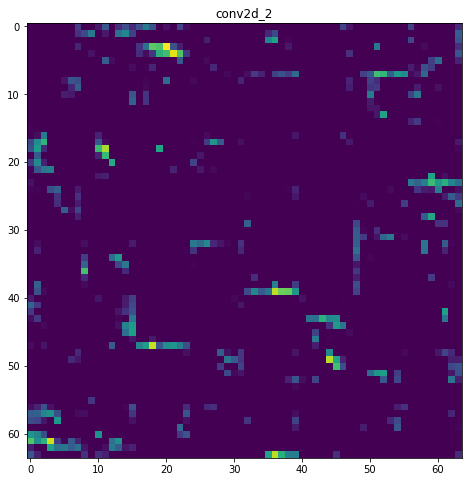

In [36]:
visualise(train_images[1])


(1, 32, 32, 3)


IndexError: ignored

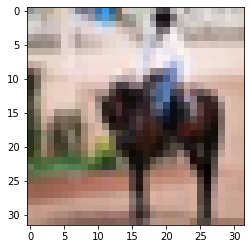

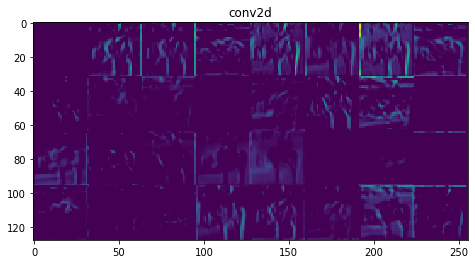

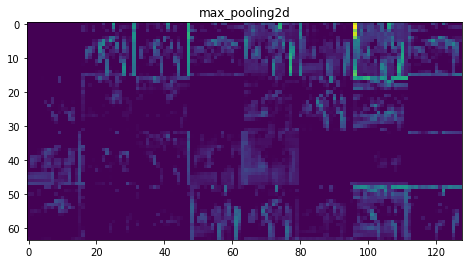

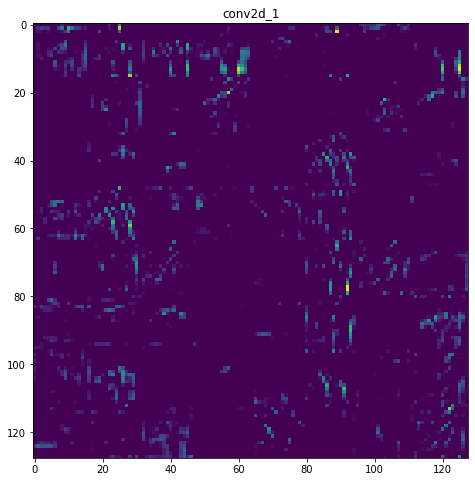

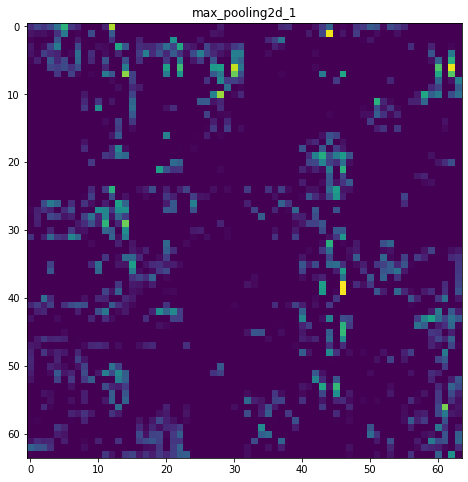

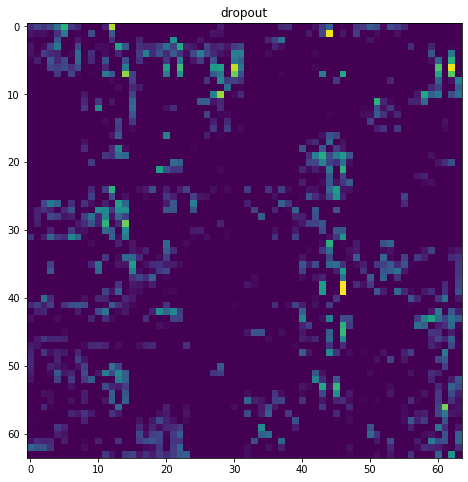

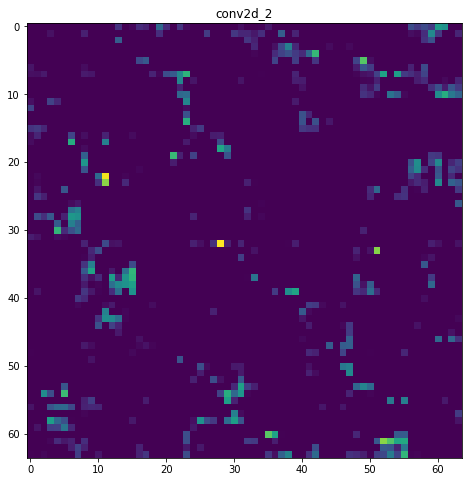

In [38]:
visualise(train_images[11])

(1, 32, 32, 3)


IndexError: ignored

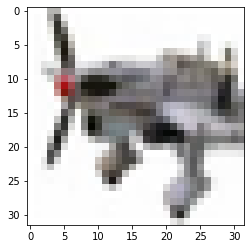

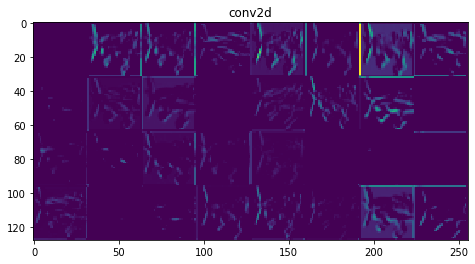

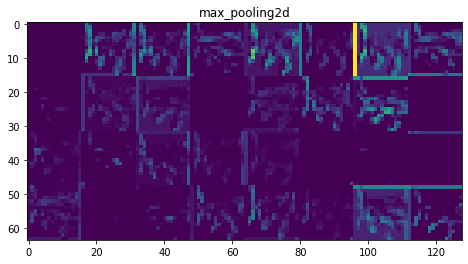

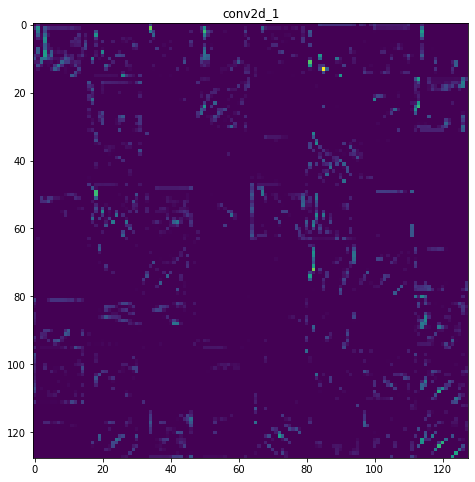

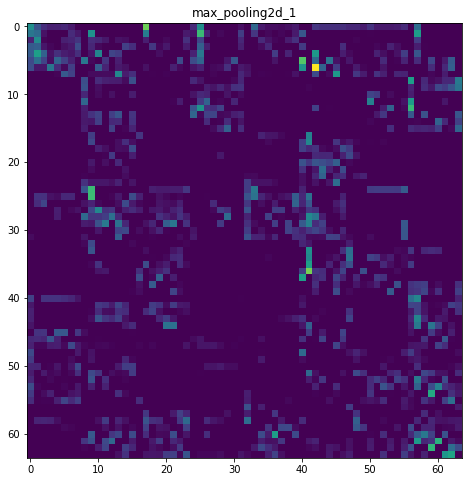

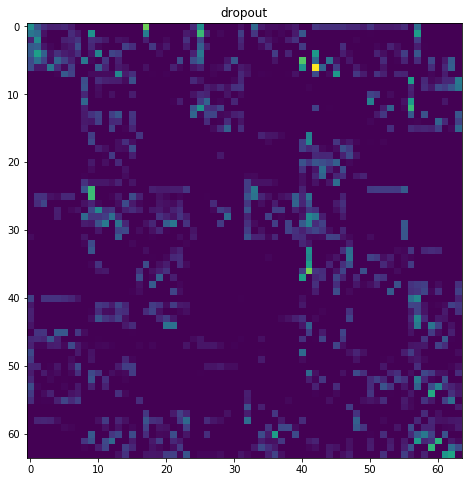

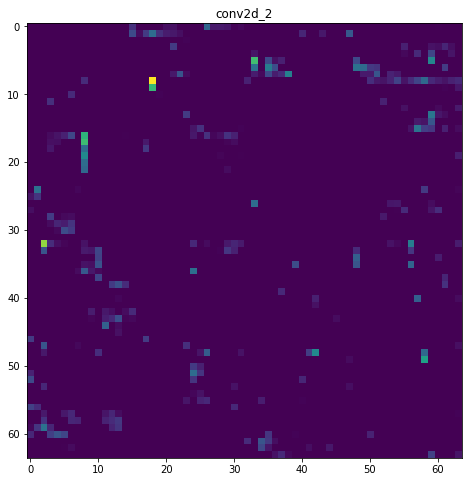

In [39]:
visualise(train_images[49])

(1, 32, 32, 3)


IndexError: ignored

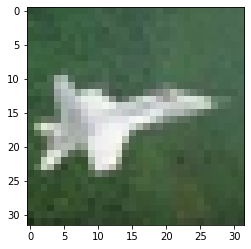

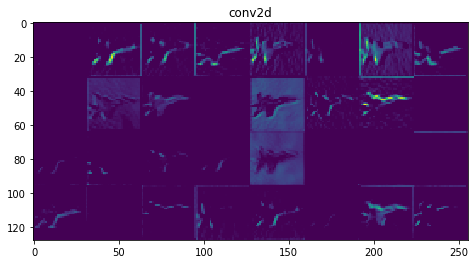

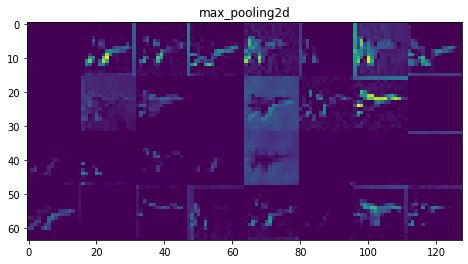

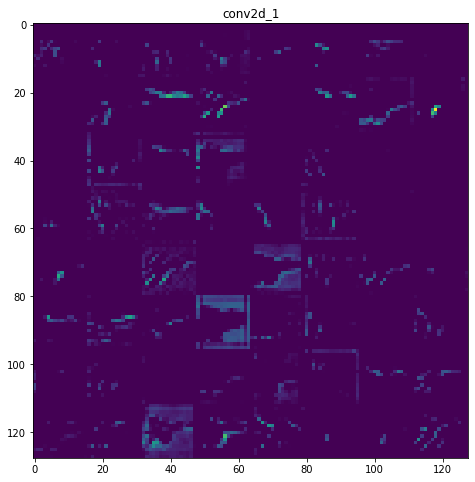

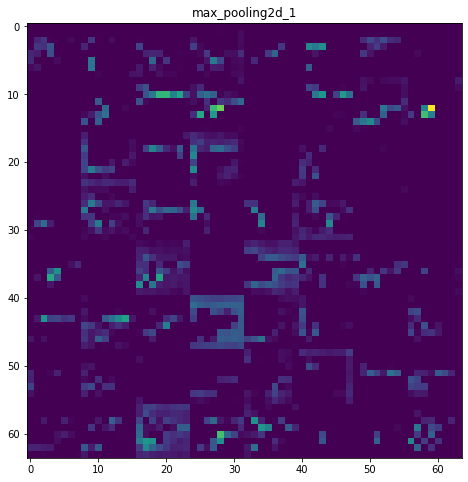

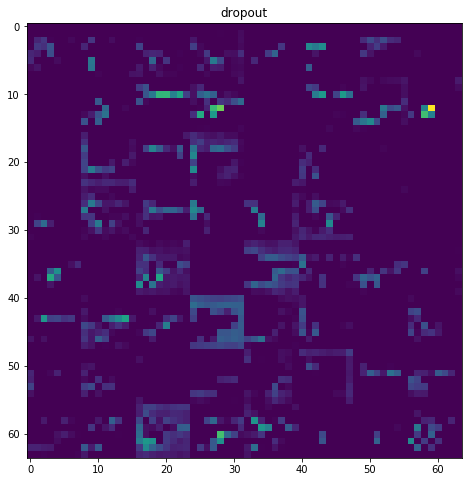

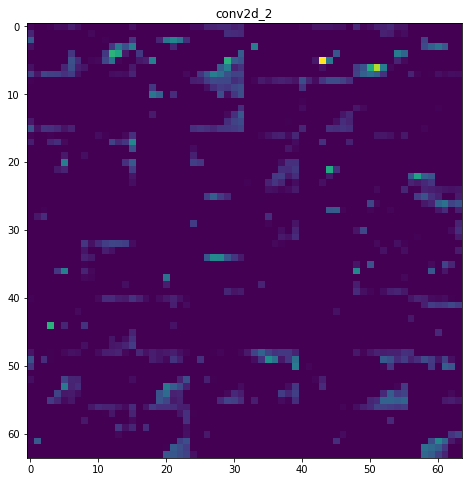

In [40]:
visualise(train_images[77])